In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_train = pd.read_csv("Files/train.csv", index_col="Id")
data_test = pd.read_csv("Files/test.csv", index_col="Id")

In [107]:
data_train["log_Sale_Price"] = np.log1p(data_train["SalePrice"])

In [112]:
data_train["SalePrice"]

Id
1       208500
2       181500
3       223500
4       140000
5       250000
         ...  
1456    175000
1457    210000
1458    266500
1459    142125
1460    147500
Name: SalePrice, Length: 1458, dtype: int64

In [ ]:
#Null Werte raus

In [34]:
data_train.isnull().sum().sort_values(ascending=False)

MSSubClass      0
Electrical      0
GarageFinish    0
GarageYrBlt     0
GarageType      0
               ..
ExterQual       0
MasVnrArea      0
MasVnrType      0
Exterior2nd     0
has_Pool        0
Length: 81, dtype: int64

In [5]:
data_train["has_Pool"] = (data_train["PoolArea"] > 0).astype(int)
data_test["has_Pool"] = (data_test["PoolArea"] > 0).astype(int)

In [163]:
data_train["has_Misc"] = (data_train["MiscVal"] > 0).astype(int)
data_test["has_Misc"] = (data_test["MiscVal"] > 0).astype(int)

In [159]:
data_train = data_train.drop(columns=["PoolArea", "PoolQC"])
data_test = data_test.drop(columns=["PoolArea", "PoolQC"])

In [164]:
data_train = data_train.drop(columns=["MiscFeature", "MiscVal"])
data_test = data_test.drop(columns=["MiscFeature", "MiscVal"])

In [9]:
data_train["MasVnrType"].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [17]:
data_train[data_train['LotFrontage'].isna()]['BldgType'].value_counts()

BldgType
1Fam      226
TwnhsE     22
Duplex      5
Twnhs       3
2fmCon      3
Name: count, dtype: int64

In [21]:
data_train["BldgType"].value_counts()

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

In [20]:
data_train[data_train["BldgType"] == "1Fam"]["LotFrontage"].value_counts()

LotFrontage
60.0     122
80.0      67
70.0      64
50.0      50
75.0      48
        ... 
160.0      1
152.0      1
41.0       1
153.0      1
46.0       1
Name: count, Length: 104, dtype: int64

In [22]:
for df in [data_train, data_test]:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

In [27]:
na_meaning = {
    "Alley": "No Alley",
    "BsmtQual": "No Basement",
    "BsmtCond": "No Basement",
    "BsmtFinType1": "No Basement",
    "BsmtFinType2": "No Basement",
    "BsmtExposure": "No Basement",
    "FireplaceQu": "No Fireplace",
    "GarageType": "No Garage",
    "GarageFinish": "No Garage",
    "GarageQual": "No Garage",
    "GarageCond": "No Garage",
    "GarageYrBlt": "No Garage",
    "PoolQC": "No Pool",
    "Fence": "No Fence",
    "MiscFeature": "No Misc",
    "MasVnrType": "None",
    "MasVnrArea": 0,
}
for col, fill_val in na_meaning.items():
    data_train[col] = data_train[col].fillna(fill_val)
    data_test[col] = data_test[col].fillna(fill_val)

In [32]:
data_train["Electrical"] = data_train["Electrical"].fillna(data_train["Electrical"].mode()[0])

In [ ]:
#Outlier

In [165]:
numericalcols = data_train.select_dtypes(include="number").columns
numericalcols

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MoSold', 'YrSold',
       'SalePrice', 'has_Pool', 'log_Sale_Price', 'has_Misc'],
      dtype='str')

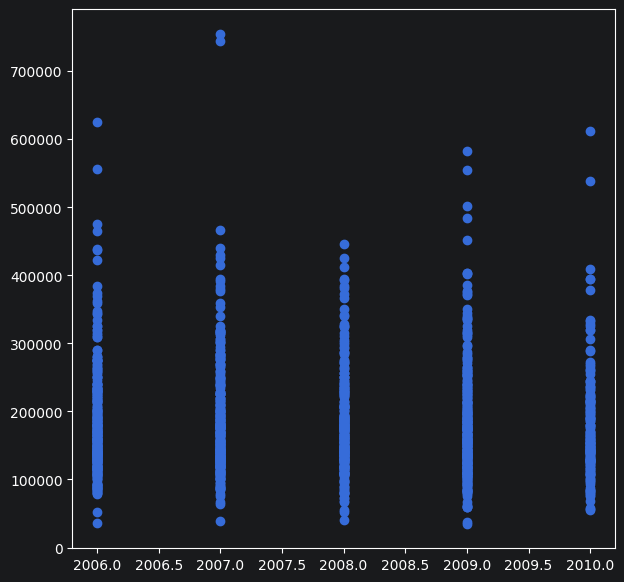

In [167]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x = data_train["YrSold"], y=data_train["SalePrice"]);
#ax.scatter(x = data_train["GarageArea"], y=data_train["log_Sale_Price"]);

In [100]:
data_train.LotArea.describe()

count     1458.000000
mean     10093.994041
std       5389.144728
min       1300.000000
25%       7544.500000
50%       9475.000000
75%      11600.000000
max      45924.392000
Name: LotArea, dtype: float64

In [151]:
upper = data_train["EnclosedPorch"].quantile(0.999)
data_train['EnclosedPorch'] = data_train["EnclosedPorch"].clip(upper=upper)

In [ ]:
upper_cl_porch = data_train["LotArea"].quantile(0.992)
data_train['LotArea'] = data_train["LotArea"].clip(upper=upper)

In [78]:
data_train.loc[data_train["BsmtFinSF2"] > 1400]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,has_Pool
Id,,,,,,,,,,,,,,,,,,,,,
323,60,RL,86.0,10380.0,Pave,No Alley,IR1,Lvl,AllPub,Inside,...,No Pool,MnPrv,No Misc,0,8,2007,WD,Normal,301000,0


In [138]:
#Problematische Zeilen (hohe qualität und generell Werte, aber niedrige Qualität)
data_train = data_train.drop(index=1299)
data_train = data_train.drop(index=524)
#Mehr Gerage als Wohnfläche
data_train = data_train.drop(index=1062)

In [98]:
data_train[data_train["LowQualFinSF"] > 550]
#der eine Eintrag ist Qualität 10 und aus 1892 und einen realistischen Preis, also kein fragwürdiger Ausreißer

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,has_Pool
Id,,,,,,,,,,,,,,,,,,,,,
186,75,RM,90.0,22950.0,Pave,No Alley,IR2,Lvl,AllPub,Inside,...,No Pool,GdPrv,No Misc,0,6,2006,WD,Normal,475000,0


In [124]:
data_train[data_train["BedroomAbvGr"] == 8]
#der Ausreißer hier hat mittlere Qualität und ist aus 1914, ist aber riesig. Sein Preis ist realistisch

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,has_Pool,log_Sale_Price
Id,,,,,,,,,,,,,,,,,,,,,
636,190,RH,60.0,10896.0,Pave,Pave,Reg,Bnk,AllPub,Inside,...,No Fence,No Misc,0,3,2007,WD,Abnorml,200000,0,12.206078


In [150]:
data_train[data_train["EnclosedPorch"] > 400][["OverallQual", "SalePrice", "GrLivArea", "Neighborhood", "EnclosedPorch"]]

,OverallQual,SalePrice,GrLivArea,Neighborhood,EnclosedPorch
Id,,,,,
198,8,235000,3112,NAmes,552


In [147]:
data_train.loc[496, ['OpenPorchSF', 'GrLivArea', 'LotArea', 'YearBuilt', 'BldgType', 'SalePrice']]

OpenPorchSF       523
GrLivArea         720
LotArea        7879.0
YearBuilt        1920
BldgType         1Fam
SalePrice       34900
Name: 496, dtype: object